投擲 1000000 次後的估計機率: 0.166770
與理論值的誤差: 0.000103


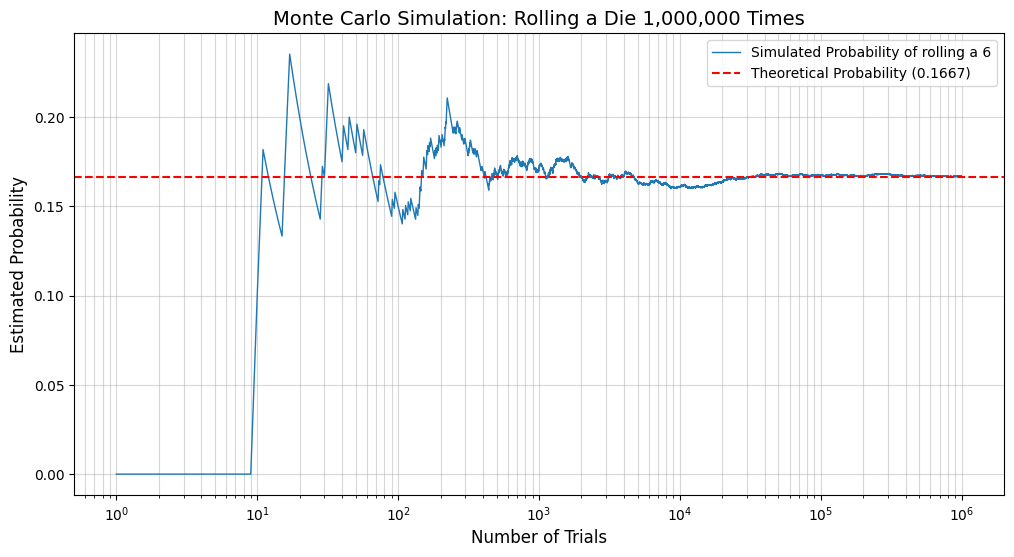

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 設定參數
n_trials = 1000000  # 投擲 1,000,000 次
target_value = 6    # 我們觀察點數 6 出現的機率

# 1. 模擬投擲骰子 (產生 1 到 6 的隨機整數)
rolls = np.random.randint(1, 7, size=n_trials)

# 2. 計算是否為目標點數 (布林陣列：True 為 1, False 為 0)
is_target = (rolls == target_value)

# 3. 計算累計出現次數與累計機率
# cumsum 會計算前 n 項的和，再除以目前的次數
cumulative_sum = np.cumsum(is_target)
trials_index = np.arange(1, n_trials + 1)
probabilities = cumulative_sum / trials_index

# 4. 繪圖
plt.figure(figsize=(12, 6))
plt.plot(trials_index, probabilities, label=f'Simulated Probability of rolling a {target_value}', color='#1f77b4', linewidth=1)

# 畫出理論機率線 (1/6)
theoretical_prob = 1/6
plt.axhline(y=theoretical_prob, color='r', linestyle='--', label=f'Theoretical Probability ({theoretical_prob:.4f})')

# 設定圖表資訊
plt.title(f'Monte Carlo Simulation: Rolling a Die {n_trials:,} Times', fontsize=14)
plt.xlabel('Number of Trials', fontsize=12)
plt.ylabel('Estimated Probability', fontsize=12)
plt.xscale('log')  # 使用對數對角，能更清楚看到前期的劇烈波動
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# 顯示最後估算的結果
print(f"投擲 {n_trials} 次後的估計機率: {probabilities[-1]:.6f}")
print(f"與理論值的誤差: {abs(probabilities[-1] - theoretical_prob):.6f}")

plt.show()

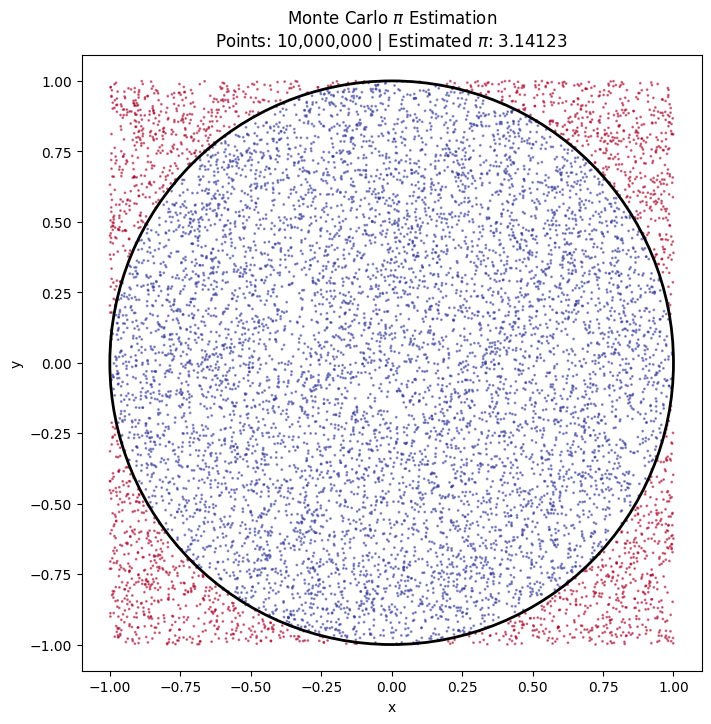

模擬 1,000,000 次後的 PI 估計值: 3.1412268
與真實 PI 的誤差: 0.000366


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 設定投擲次數
n_points = 10000000

# 1. 隨機產生 x, y 座標 (範圍在 -1 到 1 之間)
x = np.random.uniform(-1, 1, n_points)
y = np.random.uniform(-1, 1, n_points)

# 2. 計算點到原點的距離平方 (x^2 + y^2)
# 如果距離平方 <= 1，代表點在圓內
inside_circle = (x**2 + y**2) <= 1

# 3. 估算 PI
pi_estimate = 4 * np.sum(inside_circle) / n_points

# 4. 繪圖 (為了效能，我們只畫前 10,000 個點，否則圖表會跑不動)
plt.figure(figsize=(8, 8))
plt.scatter(x[:10000], y[:10000], c=inside_circle[:10000], 
            cmap='RdYlBu', s=1, alpha=0.5)

# 畫出圓形的輪廓
circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
plt.gca().add_patch(circle)

plt.title(f"Monte Carlo $\pi$ Estimation\nPoints: {n_points:,} | Estimated $\pi$: {pi_estimate:.5f}")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()

print(f"模擬 1,000,000 次後的 PI 估計值: {pi_estimate}")
print(f"與真實 PI 的誤差: {abs(pi_estimate - np.pi):.6f}")

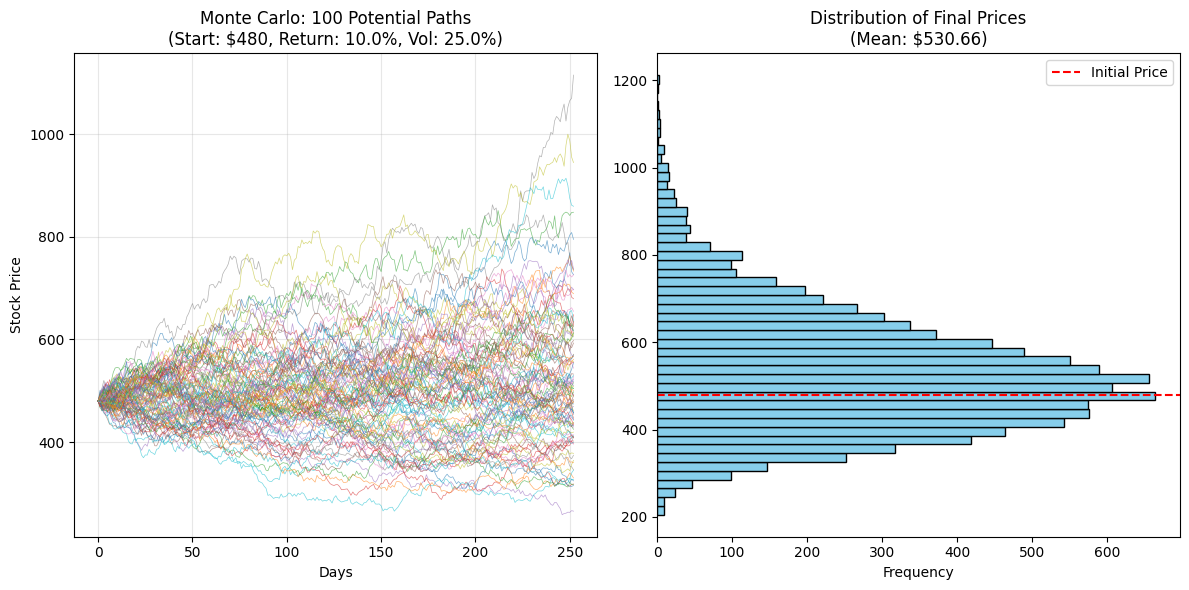

模擬結束後的平均價格: $530.66
獲利的機率 (價格 > 480): 60.94%
賠掉超過 20% 的機率: 12.63%


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 設定參數
s0 = 480       # 初始股價
mu = 0.1       # 預期年化報酬率 (10%)
sigma = 0.25   # 年化波動率 (25%)
t = 1          # 模擬時間 (1年)
n_steps = 252  # 總步數 (一年約 252 個交易日)
dt = t / n_steps
n_simulations = 10000  # 模擬 10,000 種可能走勢

# 2. 準備隨機矩陣 (利用 NumPy 向量化運算，一次產生 1萬 x 252 的隨機數)
# 這裡產生的是標準正態分佈 Z ~ N(0, 1)
z = np.random.normal(size=(n_steps, n_simulations))

# 3. 計算股價變動軌跡
# 使用 GBM 公式: S(t) = S(t-1) * exp((mu - 0.5 * sigma^2) * dt + sigma * sqrt(dt) * Z)
price_paths = np.zeros((n_steps + 1, n_simulations))
price_paths[0] = s0

for i in range(1, n_steps + 1):
    price_paths[i] = price_paths[i-1] * np.exp((mu - 0.5 * sigma**2) * dt + 
                                               sigma * np.sqrt(dt) * z[i-1])

# 4. 繪圖
plt.figure(figsize=(12, 6))

# 畫出前 100 條走勢線 (畫太多會看不清)
plt.subplot(1, 2, 1)
plt.plot(price_paths[:, :100], lw=0.5, alpha=0.6)
plt.title(f"Monte Carlo: 100 Potential Paths\n(Start: ${s0}, Return: {mu*100}%, Vol: {sigma*100}%)")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.grid(True, alpha=0.3)

# 畫出一年後最後價格的分布直方圖
plt.subplot(1, 2, 2)
final_prices = price_paths[-1]
plt.hist(final_prices, bins=50, color='skyblue', edgecolor='black', orientation='horizontal')
plt.title(f"Distribution of Final Prices\n(Mean: ${np.mean(final_prices):.2f})")
plt.xlabel("Frequency")
plt.axhline(y=s0, color='r', linestyle='--', label='Initial Price')
plt.legend()

plt.tight_layout()
plt.show()

# 5. 數據分析
print(f"模擬結束後的平均價格: ${np.mean(final_prices):.2f}")
print(f"獲利的機率 (價格 > {s0}): {np.mean(final_prices > s0) * 100:.2f}%")
print(f"賠掉超過 20% 的機率: {np.mean(final_prices < s0 * 0.8) * 100:.2f}%")

In [ ]:
py pip install seaborn

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 假設數據：
# A 方案：1000 次曝光，50 次點擊 (5%)
# B 方案：1100 次曝光，70 次點擊 (6.3%)
samples = 20000

# 從 Beta 分佈抽樣 (參數為 alpha=點擊數+1, beta=未點擊數+1)
a_samples = np.random.beta(50 + 1, (1000 - 50) + 1, samples)
b_samples = np.random.beta(70 + 1, (1100 - 70) + 1, samples)

# 計算 B 方案優於 A 方案的機率
prob_b_better_than_a = (b_samples > a_samples).mean()

print(f"B 方案優於 A 方案的機率: {prob_b_better_than_a:.2%}")

# 繪製分佈圖
sns.kdeplot(a_samples, label='Option A', fill=True)
sns.kdeplot(b_samples, label='Option B', fill=True)
plt.title("Posterior Distributions of Conversion Rates")
plt.xlabel("Conversion Rate")
plt.legend()
plt.show()